<a href="https://colab.research.google.com/github/Victor-Tung/CS171_news_classification/blob/main/CS171_news_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Investigation


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Read the features file.
train_data = pd.read_csv('/content/drive/MyDrive/CS171/ag_train.csv',header=None,
                   names=['class', 'title', 'description'])
test_data = pd.read_csv('/content/drive/MyDrive/CS171/ag_test.csv',header=None,
                   names=['class', 'title', 'description'])
#first 30 lines are all class index 3, data set is well balanced
print(train_data['class'].value_counts().sort_index())
print('-----------------------------------')
train_data.tail(5)


class
1              30000
2              30000
3              30000
4              30000
Class Index        1
Name: count, dtype: int64
-----------------------------------


,class,title,description
119996,1,Pakistan's Musharraf Says Won't Quit as Army Chief,"KARACHI (Reuters) - Pakistani President Pervez Musharraf has said he will stay on as army chief, reneging on a pledge to quit the powerful post by the end of the year."
119997,2,Renteria signing a top-shelf deal,"Red Sox general manager Theo Epstein acknowledged Edgar Renteria was more a luxury for the 2005 Red Sox than a necessity. But there's nothing wrong with getting the keys to a BMW, and that's what the four-time All-Star and two-time Gold Glover is in the eyes of the Red Sox."
119998,2,Saban not going to Dolphins yet,"The Miami Dolphins will put their courtship of LSU coach Nick Saban on hold to comply with the NFL's hiring policy by interviewing at least one minority candidate, a team source told The Associated Press last night."
119999,2,Today's NFL games,"PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: Steelers by 10. Records: Steelers 12-1, Giants 5-8. Vs. spread: Steelers 10-1-2, Giants 5-8. Series: Giants lead, 43-27-3. Comments: Think the Giants knew Ben Roethlisberger was available on draft day when they broke the bank and traded for Eli Manning? . . . All Big Ben has done this year is complete ..."
120000,2,Nets get Carter from Raptors,"INDIANAPOLIS -- All-Star Vince Carter was traded by the Toronto Raptors to the New Jersey Nets for Alonzo Mourning, Eric Williams, Aaron Williams, and a pair of first-round draft picks yesterday."


In [ ]:
train_data.shape

(120001, 3)

In [ ]:
train_data.columns

Index(['class', 'title', 'description'], dtype='object')

In [ ]:
train_data.dtypes

,0
class,object
title,object
description,object


# Data Preprocessing and Cleaning


In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)        # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()          # collapse extra whitespace
    text = ' '.join([w for w in text.split() if w not in stop_words])  # remove stopwords
    text = re.sub(r"\b(reuters|afp|ap|forbes|cnn|bbc|bloomberg)\b", "", text, flags=re.IGNORECASE)
    return text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
train_data['title_clean'] = train_data['title'].apply(clean_text)
train_data['description_clean'] = train_data['description'].apply(clean_text)
train_data['text'] = train_data['title_clean'] + ' ' + train_data['description_clean']

In [ ]:
test_data['title_clean'] = test_data['title'].apply(clean_text)
test_data['description_clean'] = test_data['description'].apply(clean_text)
test_data['text'] = test_data['title_clean'] + ' ' + test_data['description_clean']

In [ ]:
# testing clean function
test_val = 5000
print("BEFORE:", train_data['title'].iloc[test_val])
print("AFTER: ", train_data['title_clean'].iloc[test_val])
print()
print("BEFORE:", train_data['description'].iloc[test_val])
print("AFTER: ", train_data['description_clean'].iloc[test_val])
train_data.head(5)

BEFORE: General Growth Properties to acquire Rouse for \$12.6 bn
AFTER:  general growth properties acquire rouse 12 6 bn

BEFORE: NEW YORK, August 20 (New Ratings)  General Growth Properties Inc (GGP.NYS), the second-largest shopping mall operator in the US, has agreed to buy Rouse Company (RSE), in a cash and debt assumptions deal worth about \$12.6 billion. 
AFTER:  new york august 20 new ratings general growth properties inc ggp nys second largest shopping mall operator us agreed buy rouse company rse cash debt assumptions deal worth 12 6 billion


,class,title,description,title_clean,description_clean,text
0,Class Index,Title,Description,title,description,title description
1,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",wall st bears claw back black,short sellers wall street dwindling band ultra cynics seeing green,wall st bears claw back black short sellers wall street dwindling band ultra cynics seeing green
2,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.",carlyle looks toward commercial aerospace,private investment firm carlyle group reputation making well timed occasionally controversial plays defense industry quietly placed bets another part market,carlyle looks toward commercial aerospace private investment firm carlyle group reputation making well timed occasionally controversial plays defense industry quietly placed bets another part market
3,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.,oil economy cloud stocks outlook,soaring crude prices plus worries economy outlook earnings expected hang stock market next week depth summer doldrums,oil economy cloud stocks outlook soaring crude prices plus worries economy outlook earnings expected hang stock market next week depth summer doldrums
4,3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters),"Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday.",iraq halts oil exports main southern pipeline,authorities halted oil export flows main pipeline southern iraq intelligence showed rebel militia could strike infrastructure oil official said saturday,iraq halts oil exports main southern pipeline authorities halted oil export flows main pipeline southern iraq intelligence showed rebel militia could strike infrastructure oil official said saturday


# Building/Training Custom CNN


In [ ]:
train_data = train_data[train_data["class"] != "Class Index"].copy()
test_data = test_data[test_data["class"] != "Class Index"].copy()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Raw data
train_texts = train_data["text"].astype(str).values
train_labels = train_data["class"].astype(str).values  # keep as strings

test_texts = test_data["text"].astype(str).values
test_labels = test_data["class"].astype(str).values

# Map class IDs → names
class_names = {
    "1": "World",
    "2": "Sports",
    "3": "Business",
    "4": "Sci/Tech"
}

# Downsample training set
train_texts, _, train_labels, _ = train_test_split(
    train_texts,
    train_labels,
    # train_size=50000,
    random_state=42,
    stratify=train_labels
)

# Encode labels ("1"–"4" → 0–3)
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(train_labels)
y_test_int = label_encoder.transform(test_labels)

# One-hot encode
num_classes = len(label_encoder.classes_)
y_train = to_categorical(y_train_int, num_classes=num_classes)
y_test = to_categorical(y_test_int, num_classes=num_classes)

# Tokenizer
max_words = 20000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_test_seq = tokenizer.texts_to_sequences(test_texts)

X_train = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print("LabelEncoder classes:", label_encoder.classes_)
print("Class mapping:", class_names)

LabelEncoder classes: ['1' '2' '3' '4']
Class mapping: {'1': 'World', '2': 'Sports', '3': 'Business', '4': 'Sci/Tech'}


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_16         │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.6452 - loss: 0.9917 - val_accuracy: 0.8844 - val_loss: 0.4444
Epoch 2/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8873 - loss: 0.4304 - val_accuracy: 0.9061 - val_loss: 0.3516
Epoch 3/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9127 - loss: 0.3405 - val_accuracy: 0.9115 - val_loss: 0.3206
Epoch 4/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9271 - loss: 0.2857 - val_accuracy: 0.9155 - val_loss: 0.3076
Epoch 5/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9371 - loss: 0.2457 - val_accuracy: 0.9148 - val_loss: 0.3022
Epoch 6/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9481 - loss: 0.2113 - val_accuracy: 0.9124 - val_loss: 0.3040
Epoch 7/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9542 - loss: 0.1829 - val_accuracy: 0.9100 - val_loss: 0.3142


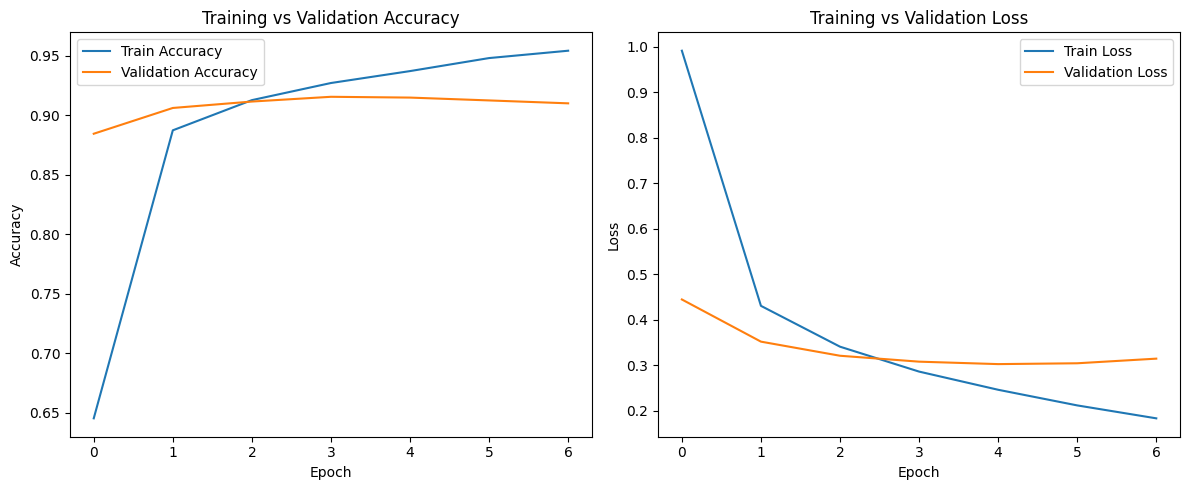

Test Loss: 0.3073
Test Accuracy: 0.9125
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report:

              precision    recall  f1-score   support

       World     0.9359    0.8916    0.9132      1900
      Sports     0.9542    0.9758    0.9649      1900
    Business     0.8735    0.8832    0.8783      1900
    Sci/Tech     0.8873    0.8995    0.8934      1900

    accuracy                         0.9125      7600
   macro avg     0.9127    0.9125    0.9124      7600
weighted avg     0.9127    0.9125    0.9124      7600


Confusion Matrix:

[[1694   60   98   48]
 [  20 1854   14   12]
 [  51   14 1678  157]
 [  45   15  131 1709]]


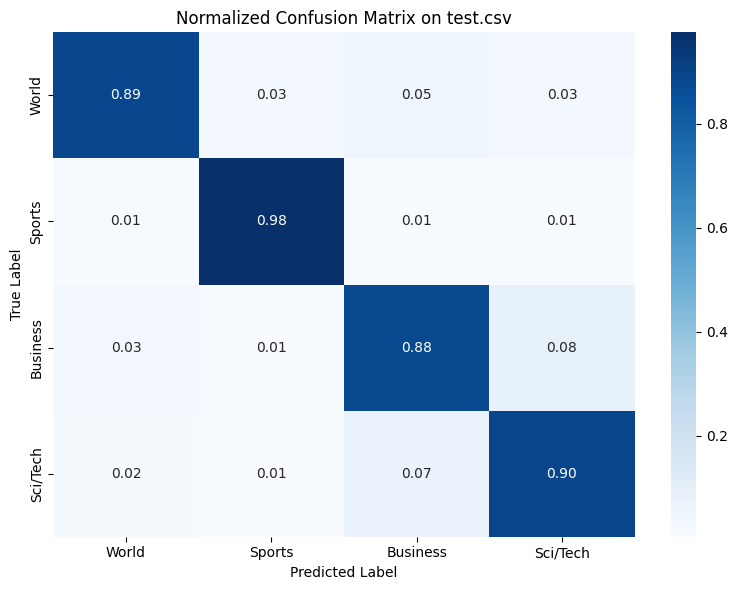

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, SpatialDropout1D
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2


embedding_dim = 128
num_classes = y_train.shape[1]

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim),
    Conv1D(filters=128, kernel_size=3, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(64, activation="relu",kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])
model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Train only on train.csv
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Test only on test.csv
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions on test.csv
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Convert encoded labels back to original IDs: "1", "2", "3", "4"
predicted_class_ids = label_encoder.inverse_transform(y_pred)
true_class_ids = label_encoder.inverse_transform(y_true)

# Convert IDs to readable class names
predicted_labels = [class_names[i] for i in predicted_class_ids]
true_labels = [class_names[i] for i in true_class_ids]

class_label_names = list(class_names.values())

print("\nClassification Report:\n")
print(classification_report(
    true_labels,
    predicted_labels,
    labels=class_label_names,
    digits=4
))

cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=class_label_names
)

print("\nConfusion Matrix:\n")
print(cm)

cm_normalized = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_label_names,
    yticklabels=class_label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix on test.csv")
plt.tight_layout()
plt.show()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_23        │ (None, 100, 128)  │  2,560,000 │ input_layer_17[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_7 │ (None, 100, 128)  │          0 │ embedding_23[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 98, 32)    │     12,320 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 96, 32)    │     20,512 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 94, 32)    │     28,704 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv1d_24[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv1d_25[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv1d_26[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 96)        │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 32)        │      3,104 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 32)        │          0 │ dense_36[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 4)         │        132 │ dropout_31[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,624,772 (10.01 MB)

 Trainable params: 2,624,772 (10.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - accuracy: 0.8448 - loss: 0.4667 - val_accuracy: 0.9093 - val_loss: 0.2756
Epoch 2/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9187 - loss: 0.2624 - val_accuracy: 0.9075 - val_loss: 0.2759
Epoch 3/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9401 - loss: 0.1843 - val_accuracy: 0.9105 - val_loss: 0.3080


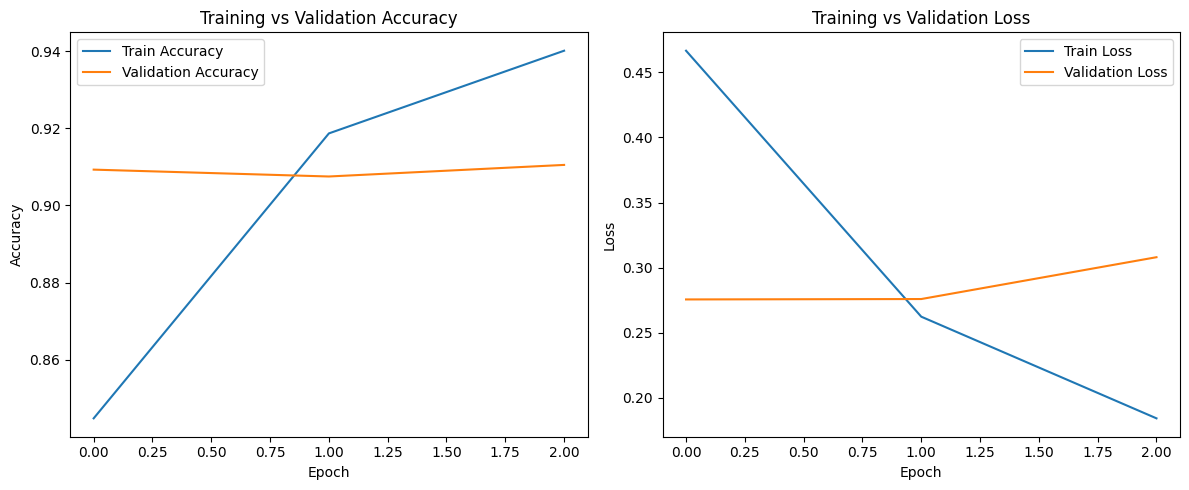

Test Loss: 0.2877
Test Accuracy: 0.9061
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report:

              precision    recall  f1-score   support

       World     0.9266    0.8900    0.9079      1900
      Sports     0.9466    0.9805    0.9633      1900
    Business     0.8898    0.8416    0.8650      1900
    Sci/Tech     0.8622    0.9121    0.8864      1900

    accuracy                         0.9061      7600
   macro avg     0.9063    0.9061    0.9057      7600
weighted avg     0.9063    0.9061    0.9057      7600


Confusion Matrix:

[[1691   63   98   48]
 [  18 1863    9   10]
 [  60   22 1599  219]
 [  56   20   91 1733]]


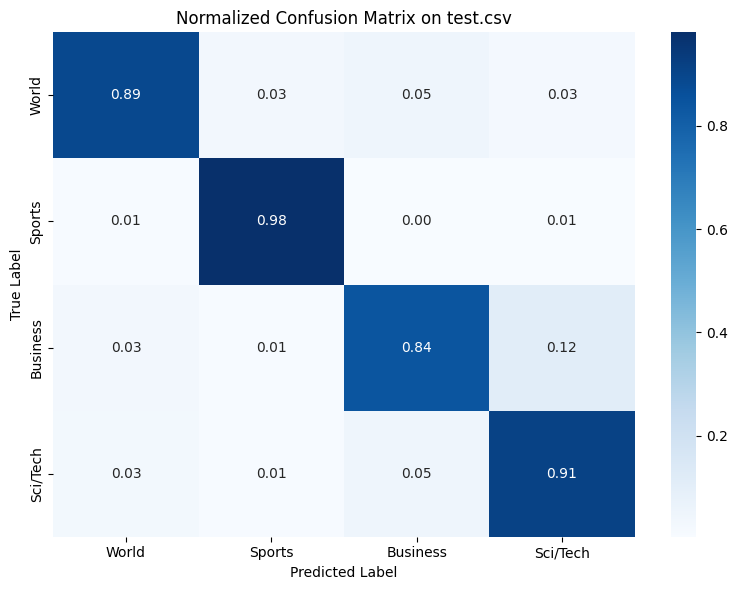

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, SpatialDropout1D,
    Conv1D, GlobalMaxPooling1D, Concatenate,
    Dense, Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

embedding_dim = 128
num_classes = y_train.shape[1]

input_layer = Input(shape=(max_len,))

x = Embedding(
    input_dim=max_words,
    output_dim=embedding_dim
)(input_layer)

x = SpatialDropout1D(0.2)(x)

# --- Parallel convolution blocks ---
conv3 = Conv1D(32, kernel_size=3, activation="relu")(x)
conv5 = Conv1D(32, kernel_size=5, activation="relu")(x)
conv7 = Conv1D(32, kernel_size=7, activation="relu")(x)

pool3 = GlobalMaxPooling1D()(conv3)
pool5 = GlobalMaxPooling1D()(conv5)
pool7 = GlobalMaxPooling1D()(conv7)

# Combine all features
x = Concatenate()([pool3, pool5, pool7])

# Dense layers
x = Dense(32, activation="relu")(x)
x = Dropout(0.5)(x)

output_layer = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Test only on test.csv
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions on test.csv
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Convert encoded labels back to original IDs: "1", "2", "3", "4"
predicted_class_ids = label_encoder.inverse_transform(y_pred)
true_class_ids = label_encoder.inverse_transform(y_true)

# Convert IDs to readable class names
predicted_labels = [class_names[i] for i in predicted_class_ids]
true_labels = [class_names[i] for i in true_class_ids]

class_label_names = list(class_names.values())

print("\nClassification Report:\n")
print(classification_report(
    true_labels,
    predicted_labels,
    labels=class_label_names,
    digits=4
))

cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=class_label_names
)

print("\nConfusion Matrix:\n")
print(cm)

cm_normalized = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_label_names,
    yticklabels=class_label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix on test.csv")
plt.tight_layout()
plt.show()

# Fine-tuning DistilBERT

Install and Imports


In [ ]:
!pip install transformers accelerate -q

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset, Dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, get_linear_schedule_with_warmup

from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

import pandas as pd
from sklearn.preprocessing import LabelEncoder

train_data = pd.read_csv('/content/drive/MyDrive/CS171/ag_train.csv', header=None,
                         names=['class', 'title', 'description'])
test_data  = pd.read_csv('/content/drive/MyDrive/CS171/ag_test.csv', header=None,
                         names=['class', 'title', 'description'])

train_data = train_data[train_data["class"] != "Class Index"].copy()
test_data  = test_data[test_data["class"] != "Class Index"].copy()

class_names = {"1": "World", "2": "Sports", "3": "Business", "4": "Sci/Tech"}
num_classes = 4

label_encoder = LabelEncoder()
label_encoder.fit(train_data["class"].astype(str).values)

Using device: cuda


LabelEncoder()

Prepare Raw Text

In [ ]:
train_data_clean = train_data[train_data["class"] != "Class Index"].copy()
test_data_clean  = test_data[test_data["class"] != "Class Index"].copy()

distil_train_texts = (
    train_data_clean["title"].fillna("") + ". " + train_data_clean["description"].fillna("")
).astype(str).values

distil_test_texts = (
    test_data_clean["title"].fillna("") + ". " + test_data_clean["description"].fillna("")
).astype(str).values

from sklearn.model_selection import train_test_split

distil_train_texts, _, distil_train_labels, _ = train_test_split(
    distil_train_texts,
    train_data_clean["class"].astype(str).values,
    train_size=50000,
    random_state=42,
    stratify=train_data_clean["class"].astype(str).values
)

distil_test_labels = test_data_clean["class"].astype(str).values

distil_y_train_int = label_encoder.transform(distil_train_labels)
distil_y_test_int = label_encoder.transform(distil_test_labels)
print(f"Train: {len(distil_train_texts):,} | Test: {len(distil_test_texts):,}")

Train: 50,000 | Test: 7,600


Tokenizer and Dataset

In [ ]:
DISTIL_MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 3
LR = 2e-5

distil_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

class AGNewsDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_len):
    self.texts = list(texts)
    self.labels = list(labels)
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.texts)
  def __getitem__(self, idx):
    enc = self.tokenizer(
        self.texts[idx],
        max_length = self.max_len,
        padding = "max_length",
        truncation = True,
        return_tensors = "pt"
    )
    return {
        "input_ids": enc["input_ids"].squeeze(0),
        "attention_mask": enc["attention_mask"].squeeze(0),
        "labels": torch.tensor(self.labels[idx], dtype=torch.long)
    }
train_dataset = AGNewsDataset(distil_train_texts, distil_y_train_int, distil_tokenizer, DISTIL_MAX_LEN)
test_dataset = AGNewsDataset(distil_test_texts, distil_y_test_int, distil_tokenizer, DISTIL_MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=2, pin_memory=True)
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 1563 | Test batches: 238


Training

In [ ]:
distil_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_classes,
)
distil_model.to(device)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.1)

optimizer = AdamW(distil_model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(distil_model)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
def train_epoch(model, loader, optimizer, scheduler):
  model.train()
  total_loss, correct, n = 0.0, 0, 0
  for step, batch in enumerate(loader):
    ids = batch["input_ids"].to(device)
    mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    optimizer.zero_grad()
    output = model(input_ids=ids, attention_mask=mask, labels=labels)
    output.loss.backward()
    optimizer.step()
    scheduler.step()

    preds = output.logits.argmax(dim=1)
    correct += (preds == labels).sum().item()
    total_loss += output.loss.item() * labels.size(0)
    n += labels.size(0)
    if (step + 1 ) % 100 == 0:
      print(f" step {step+1}/{len(loader)} | loss: {total_loss/n:.4f} | acc: {correct/n:.4f}")

  return total_loss / n, correct / n

def evaluate_epoch(model, loader):
  model.eval()
  total_loss, correct, n = 0.0, 0, 0
  with torch.no_grad():
    for batch in loader:
      ids = batch["input_ids"].to(device)
      mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)
      output = model(input_ids=ids, attention_mask=mask, labels=labels)
      preds = output.logits.argmax(dim=1)
      correct += (preds == labels).sum().item()
      total_loss += output.loss.item() * labels.size(0)
      n += labels.size(0)
  return total_loss / n, correct / n

distil_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
  print(f"\n Epoch {epoch}/ {EPOCHS}")
  train_loss, train_acc = train_epoch(distil_model, train_loader, optimizer, scheduler)
  val_loss, val_acc = evaluate_epoch(distil_model, test_loader)
  distil_history["train_loss"].append(train_loss)
  distil_history["train_acc"].append(train_acc)
  distil_history["val_loss"].append(val_loss)
  distil_history["val_acc"].append(val_acc)
  print(f" Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
  print(f" Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")


 Epoch 1/ 3
 step 100/1563 | loss: 1.3410 | acc: 0.3762
 step 200/1563 | loss: 1.0273 | acc: 0.6155
 step 300/1563 | loss: 0.8034 | acc: 0.7067
 step 400/1563 | loss: 0.6854 | acc: 0.7520
 step 500/1563 | loss: 0.6103 | acc: 0.7808
 step 600/1563 | loss: 0.5561 | acc: 0.8023
 step 700/1563 | loss: 0.5163 | acc: 0.8163
 step 800/1563 | loss: 0.4839 | acc: 0.8285
 step 900/1563 | loss: 0.4552 | acc: 0.8393
 step 1000/1563 | loss: 0.4324 | acc: 0.8474
 step 1100/1563 | loss: 0.4130 | acc: 0.8546
 step 1200/1563 | loss: 0.3980 | acc: 0.8602
 step 1300/1563 | loss: 0.3845 | acc: 0.8650
 step 1400/1563 | loss: 0.3723 | acc: 0.8694
 step 1500/1563 | loss: 0.3624 | acc: 0.8729
 Train loss: 0.3563 | Train acc: 0.8749
 Val loss: 0.2114 | Val acc: 0.9270

 Epoch 2/ 3
 step 100/1563 | loss: 0.1658 | acc: 0.9428
 step 200/1563 | loss: 0.1615 | acc: 0.9458
 step 300/1563 | loss: 0.1619 | acc: 0.9453
 step 400/1563 | loss: 0.1625 | acc: 0.9452
 step 500/1563 | loss: 0.1608 | acc: 0.9454
 step 600/15

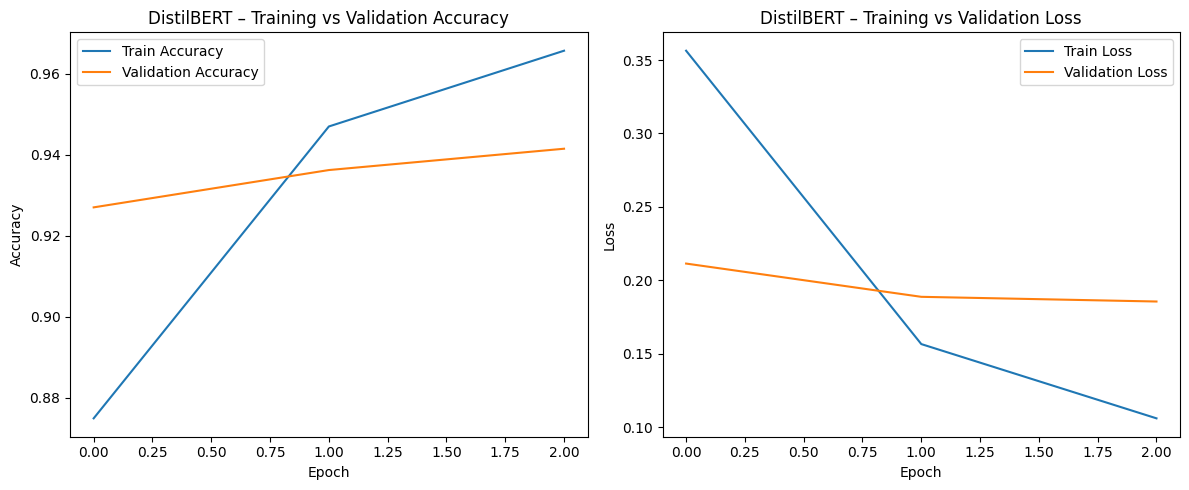

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(distil_history["train_acc"], label="Train Accuracy")
plt.plot(distil_history["val_acc"],   label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DistilBERT – Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(distil_history["train_loss"], label="Train Loss")
plt.plot(distil_history["val_loss"],   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT – Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

Test Accuracy (DistilBERT): 0.9414

Classification Report:

              precision    recall  f1-score   support

       World     0.9512    0.9537    0.9524      1900
      Sports     0.9884    0.9868    0.9876      1900
    Business     0.9178    0.8995    0.9086      1900
    Sci/Tech     0.9086    0.9258    0.9171      1900

    accuracy                         0.9414      7600
   macro avg     0.9415    0.9414    0.9414      7600
weighted avg     0.9415    0.9414    0.9414      7600



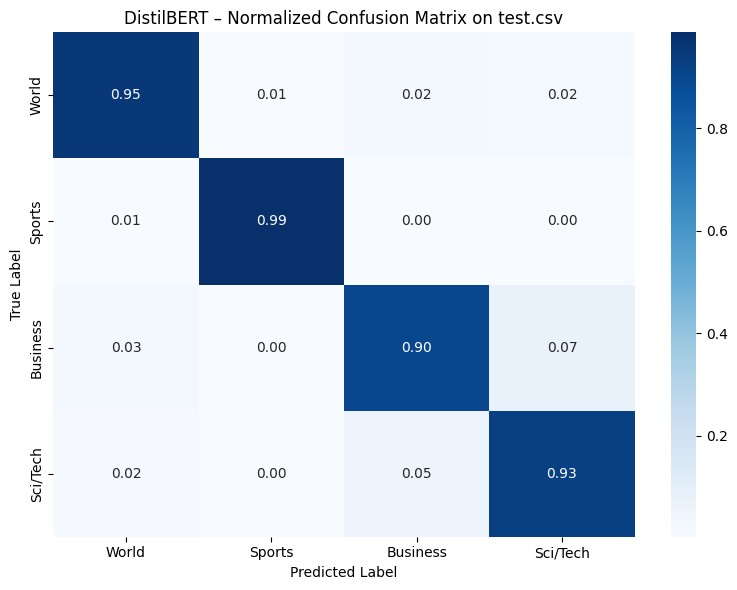

In [ ]:
distil_model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for batch in test_loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        out  = distil_model(input_ids=ids, attention_mask=mask)
        all_preds.extend(out.logits.argmax(dim=1).cpu().numpy())
        all_true.extend(batch["labels"].numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

test_acc_distil = (all_preds == all_true).mean()
print(f"Test Accuracy (DistilBERT): {test_acc_distil:.4f}")

predicted_class_ids = label_encoder.inverse_transform(all_preds)
true_class_ids      = label_encoder.inverse_transform(all_true)
predicted_labels    = [class_names[i] for i in predicted_class_ids]
true_labels_named   = [class_names[i] for i in true_class_ids]

class_label_names = list(class_names.values())

print("\nClassification Report:\n")
print(classification_report(
    true_labels_named,
    predicted_labels,
    labels=class_label_names,
    digits=4,
))

cm = confusion_matrix(true_labels_named, predicted_labels, labels=class_label_names)
cm_normalized = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_label_names,
    yticklabels=class_label_names,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DistilBERT – Normalized Confusion Matrix on test.csv")
plt.tight_layout()
plt.show()

# Compare/Constrast Results